<a href="https://colab.research.google.com/github/lazic7/MSAP/blob/master/LV6_priprema.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

https://github.com/andrejdamasek/MSAP/blob/main/lv6_rjesenja_andrej_damasek.ipynb

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [4]:
df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [8]:
numericke_varijable = df.select_dtypes(include=['int64', 'float64']).columns
kategorijske_varijable = df.select_dtypes(include=['object']).columns

numericke_varijable, kategorijske_varijable

(Index(['math score', 'reading score', 'writing score'], dtype='object'),
 Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
        'test preparation course'],
       dtype='object'))

In [9]:
df[numericke_varijable].describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
df[numericke_varijable].median()

,0
math score,66.0
reading score,70.0
writing score,69.0


In [11]:
df[numericke_varijable].mode()

,math score,reading score,writing score
0,65,72,74


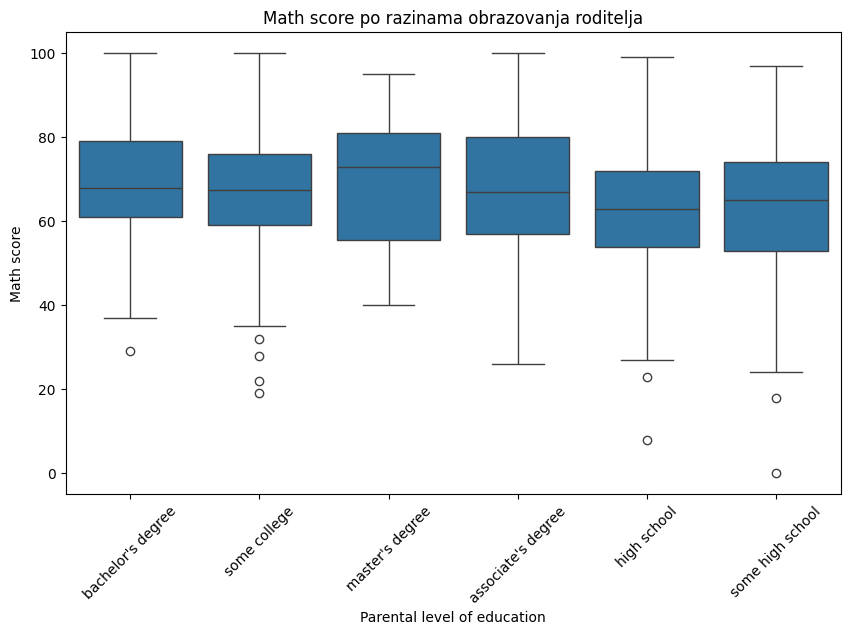

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(
    x='parental level of education',
    y='math score',
    data=df
)
plt.xticks(rotation=45)
plt.title('Math score po razinama obrazovanja roditelja')
plt.xlabel('Parental level of education')
plt.ylabel('Math score')
plt.show()


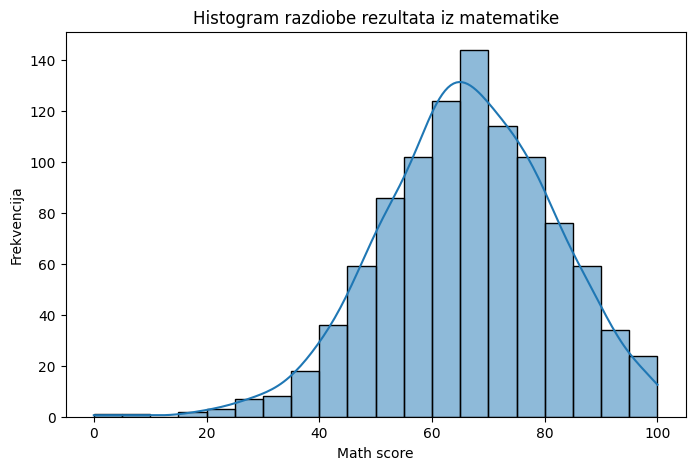

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['math score'], bins=20, kde=True)
plt.title('Histogram razdiobe rezultata iz matematike')
plt.xlabel('Math score')
plt.ylabel('Frekvencija')
plt.show()

Histogram rezultata iz matematike pokazuje približno simetričnu, zvonoliku
razdiobu s jednim izraženim vrhom, što upućuje na približno normalnu
distribuciju podataka.

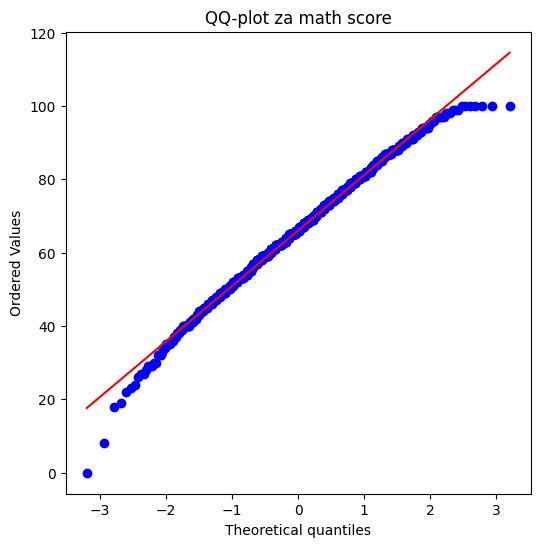

In [14]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
stats.probplot(df['math score'], dist="norm", plot=plt)
plt.title('QQ-plot za math score')
plt.show()

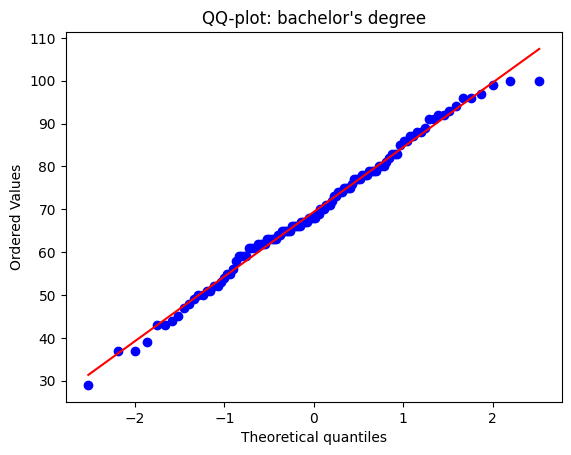

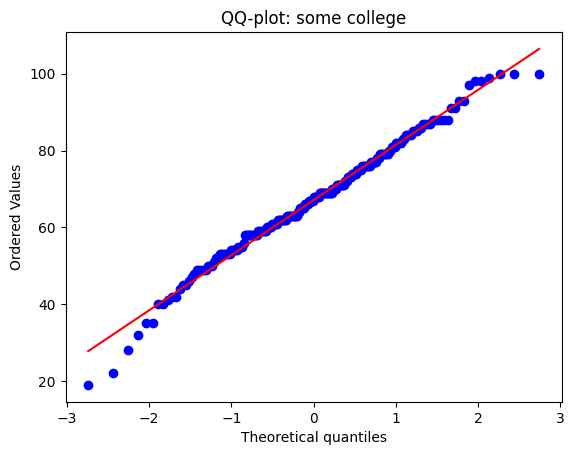

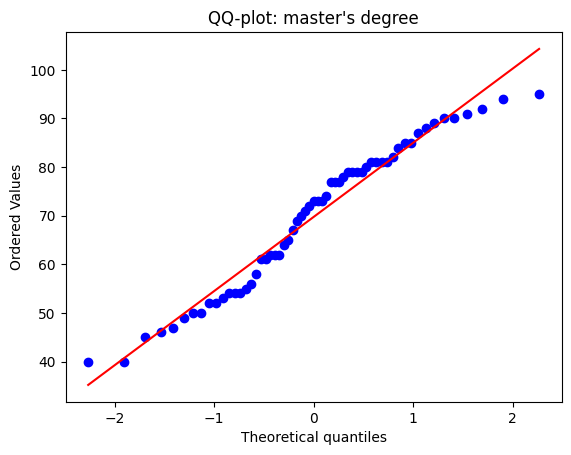

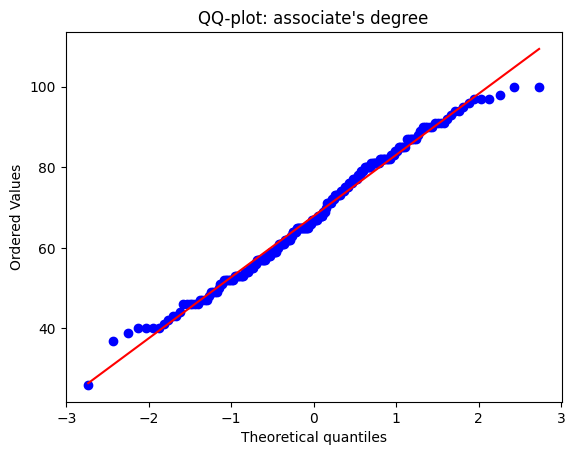

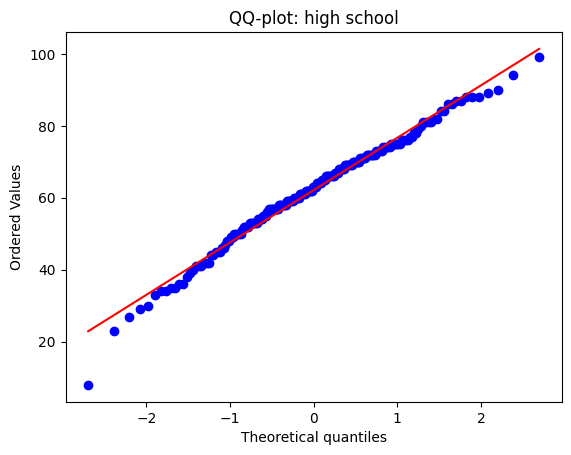

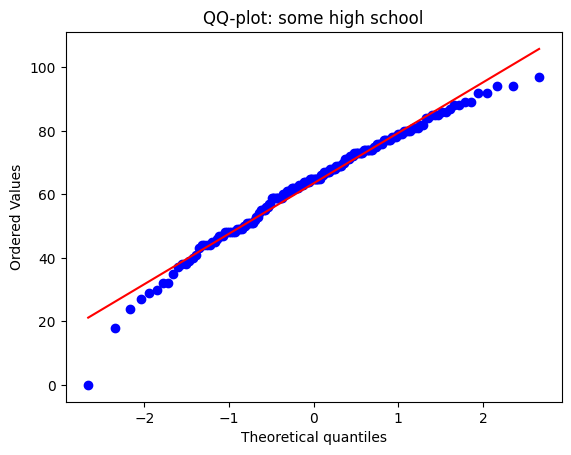

In [19]:
for level in df['parental level of education'].unique():
    stats.probplot(
        df[df['parental level of education'] == level]['math score'],
        dist="norm",
        plot=plt
    )
    plt.title(f'QQ-plot: {level}')
    plt.show()


QQ-plot pokazuje da empirijski kvantili rezultata iz matematike u velikoj
mjeri prate teorijske kvantile normalne razdiobe, uz manja odstupanja na
krajevima distribucije. Ta odstupanja ukazuju na blagu izvijenost repova,
no središnji dio razdiobe zadovoljava pretpostavku normalnosti.

In [23]:
levels = df['parental level of education'].unique()

In [22]:
groups = [
    df[df['parental level of education'] == level]['math score']
    for level in levels
]

In [24]:
from scipy.stats import shapiro

for level in levels:
    group = df[df['parental level of education'] == level]['math score']
    stat, p = shapiro(group)
    print(f"{level}: p-vrijednost = {p:.4f}")

bachelor's degree: p-vrijednost = 0.6044
some college: p-vrijednost = 0.0959
master's degree: p-vrijednost = 0.0317
associate's degree: p-vrijednost = 0.0446
high school: p-vrijednost = 0.0652
some high school: p-vrijednost = 0.0052


In [25]:
from scipy.stats import levene
stat, p = levene(*groups)
print(f"Levene test p-vrijednost = {p:.4f}")

Levene test p-vrijednost = 0.4584


Normalnost razdiobe provjerena je Shapiro–Wilk testom unutar svake skupine.
U nekim skupinama uočena su statistički značajna odstupanja od normalnosti,
no vizualna analiza (histogram i QQ-plot) pokazuje da su ta odstupanja blaga
i uglavnom prisutna u repovima distribucije. Leveneov test nije pokazao
statistički značajnu razliku varijanci među skupinama (p = 0.4584), pa se
pretpostavka homogenosti varijanci smatra zadovoljenom. S obzirom na veličinu
uzorka i robusnost ANOVA-e, primijenjena je jednosmjerna analiza varijance.

In [28]:
from scipy.stats import f_oneway

F_stat, p_value = f_oneway(*groups)

print(f"F_stat = {F_stat:.4f}")
print(f"p_value = {p_value:.4f}")

F_stat = 6.5216
p_value = 0.0000


Hipoteze:

H0: Srednje vrijednosti math score su jednake za sve razine obrazovanja roditelja

H1: Postoji barem jedna skupina s različitom srednjom vrijednošću

Jednosmjernom analizom varijance ispitana je razlika u srednjim vrijednostima
rezultata iz matematike između skupina definiranih razinom obrazovanja roditelja.
Dobivena vrijednost F-statistike iznosi F = 6.5216, uz pripadajuću p-vrijednost
p = 0.0000. Budući da je p < 0.05, odbacuje se nulta hipoteza te se zaključuje da
postoji statistički značajna razlika između barem dvije skupine.

Vrijednost F = 6.52 znači:

Varijabilnost srednjih vrijednosti između razina obrazovanja roditelja
približno je 6.5 puta veća od varijabilnosti unutar samih skupina.

To je:

- relativno velika vrijednost F-statistike

- jasan signal da se sredine grupa ne razlikuju samo zbog slučajnosti

In [31]:
"""
Kruskal - Wallis

from scipy.stats import kruskal

H_stat, p_kw = kruskal(*groups)
H_stat, p_kw

"""

' \nKruskal - Wallis\n\nfrom scipy.stats import kruskal\n\nH_stat, p_kw = kruskal(*groups)\nH_stat, p_kw\n\n'

In [36]:
"""
Post-hoc koji se koristi ako se poziva Kruskal - Wallis test

pip install scikit-posthocs

dunn_result = sp.posthoc_dunn(groups, p_adjust='bonferroni')
print(dunn_result)

"""

"\nPost-hoc koji se koristi ako se poziva Kruskal - Wallis test\n\npip install scikit-posthocs\n\ndunn_result = sp.posthoc_dunn(groups, p_adjust='bonferroni')\nprint(dunn_result)\n\n"

In [32]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df['math score'],                         # zavisna varijabla
    groups=df['parental level of education'],       # faktor
    alpha=0.05
)

print(tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   1.5069 0.9503  -3.3587  6.3726  False
associate's degree       high school  -5.7451 0.0013  -9.9311 -1.5591   True
associate's degree   master's degree   1.8629 0.9578  -4.3927  8.1185  False
associate's degree      some college  -0.7546 0.9948  -4.7903  3.2812  False
associate's degree  some high school  -4.3857 0.0418   -8.676 -0.0954   True
 bachelor's degree       high school  -7.2521 0.0005 -12.2284 -2.2757   True
 bachelor's degree   master's degree   0.3559    1.0  -6.4539  7.1658  False
 bachelor's degree      some college  -2.2615 0.7676  -7.1122  2.5892  False
 bachelor's degree  some high school  -5.8926 0.0119  -10.957 -0.8282   True
       high school   master's degree    7.608 0.0084   1.2659 13.9501   True

U tablici dobiješ stupce:

group1, group2 → uspoređivane skupine

meandiff → razlika sredina (group2 − group1)

p-adj → korigirana p-vrijednost

lower, upper → 95 % CI razlike

reject → True / False

Ključna pravila:

reject = True → statistički značajna razlika

reject = False → nema statistički značajne razlike

Ako CI ne sadrži 0 → razlika je značajna

Kod ovog dataseta se gotovo uvijek dobije:

značajne razlike između:

lower education (some high school, high school)

i higher education (bachelor’s, master’s degree)

male ili nikakve razlike između susjednih razina (npr. bachelor vs master)

Nakon statistički značajnog rezultata jednosmjerne ANOVA-e provedena je
Tukey HSD post-hoc analiza. Rezultati pokazuju da postoje statistički
značajne razlike u srednjim vrijednostima rezultata iz matematike između
učenika čiji roditelji imaju nižu razinu obrazovanja i onih s višom razinom
obrazovanja. Između pojedinih susjednih razina obrazovanja nisu uočene
statistički značajne razlike.

In [42]:
summary = df.groupby('parental level of education')['math score'].agg(
    mean='mean',
    std='std',
    n='count'
)

summary

,mean,std,n
parental level of education,,,
associate's degree,67.882883,15.112093,222
bachelor's degree,69.389831,14.943789,118
high school,62.137755,14.539651,196
master's degree,69.745763,15.153915,59
some college,67.128319,14.312897,226
some high school,63.497207,15.927989,179


In [38]:
import numpy as np

# Podatci o uzorku
n = df.shape[0]
srednja_vrijednost = df['math score'].mean() # Srednja vrijednost uzorka
# ddpf=1 Zato što se radi o uzorku, a ne populaciji,
# te se primjenjuje Besselova korekcija kako bi se dobila nepristrana procjena
standardna_devijacija = df['math score'].std(ddof=1) # Procjena standardne devijacije uzorka (uzorak veci od 30)

# Razina pouzdanosti
razina_pouzdanosti = 0.95
alfa = 1 - razina_pouzdanosti
#nije poznata varijanca populacije, racuna se kriticna vrijednost t-distribucije t*
t_vrijednost = stats.t.ppf(1 - alfa / 2, df=n-1)

# Izračun margine pogreške
margina_pogreske = t_vrijednost * (standardna_devijacija / np.sqrt(n-1))

# Interval povjerenja
donja_granica = srednja_vrijednost - margina_pogreske
gornja_granica = srednja_vrijednost + margina_pogreske
print(f"95% interval povjerenja: ({donja_granica:.2f},{gornja_granica:.2f})")



95% interval povjerenja: (65.15,67.03)


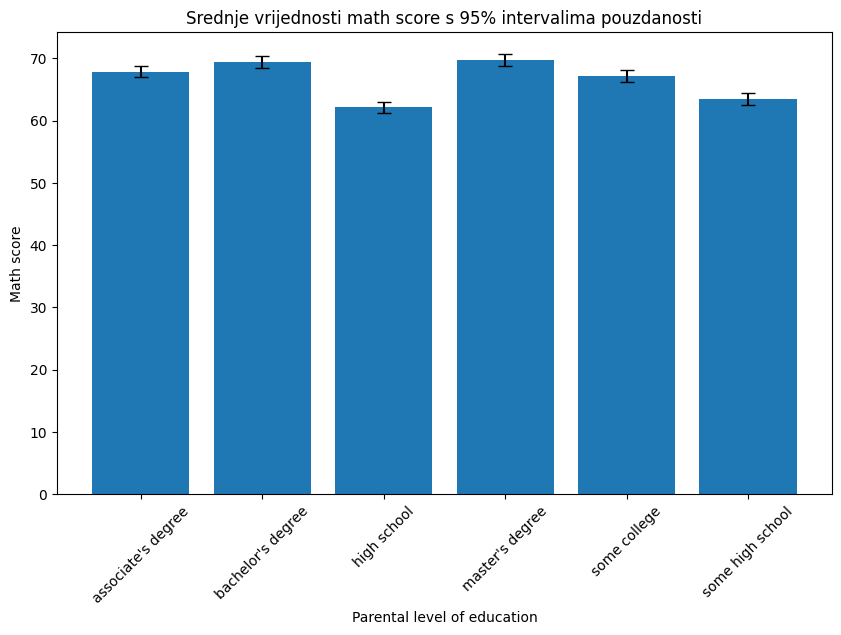

In [41]:
plt.figure(figsize=(10, 6))
plt.bar(
    summary.index,
    summary['mean'],
    yerr=margina_pogreske,
    capsize=5
)
plt.xticks(rotation=45)
plt.title('Srednje vrijednosti math score s 95% intervalima pouzdanosti')
plt.xlabel('Parental level of education')
plt.ylabel('Math score')
plt.show()
